In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import data_processing
from data_processing import vertical_profile_plot as vpp
from importlib import reload

In [4]:
h2o_data = xr.open_dataset('ACEFTS_L2_v5p2_H2O.nc')
h2o_flags = xr.open_dataset('ACEFTS_L2_v5p2_flags_H2O.nc')

In [5]:
h2o_data = h2o_data.set_index(index=['orbit', 'sunset_sunrise'])
h2o_flags = h2o_flags.set_index(index=['orbit', 'sunset_sunrise'])

In [14]:
print(h2o_data.data_vars)
print(h2o_data['altitude'].values)
print(np.where(h2o_data['altitude']==35.5)[0])

Data variables:
    year             (index) float64 1MB ...
    month            (index) float64 1MB ...
    day              (index) float64 1MB ...
    hour             (index) float64 1MB ...
    start_timetag    (index) float64 1MB ...
    latitude         (index) float64 1MB ...
    longitude        (index) float64 1MB ...
    beta_angle       (index) float64 1MB ...
    H2O              (index, altitude) float32 76MB ...
    H2O_error        (index, altitude) float32 76MB ...
    temperature      (index, altitude) float32 76MB ...
    temperature_fit  (index, altitude) float32 76MB ...
    pressure         (index, altitude) float32 76MB ...
    density          (index, altitude) float32 76MB ...
[  0.5   1.5   2.5   3.5   4.5   5.5   6.5   7.5   8.5   9.5  10.5  11.5
  12.5  13.5  14.5  15.5  16.5  17.5  18.5  19.5  20.5  21.5  22.5  23.5
  24.5  25.5  26.5  27.5  28.5  29.5  30.5  31.5  32.5  33.5  34.5  35.5
  36.5  37.5  38.5  39.5  40.5  41.5  42.5  43.5  44.5  45.5  46.5  4

In [9]:
years = h2o_data['year'].values
months = h2o_data['month'].values
days = h2o_data['day'].values
hours = h2o_data['hour'].values
times = pd.to_datetime({
    'year': years,
    'month': months,
    'day': days,
    'hour': hours
})

In [10]:
print(times.max())

2024-10-18 07:02:44.729999998


In [21]:
bad_profile_indices = []
for i in range(0, len(times)-1):
    orbit_number = h2o_data['orbit'][i].values
    ss = h2o_data['sunset_sunrise'][i].values

    try:
        flag_profile = h2o_flags['quality_flag'].sel(orbit=orbit_number, sunset_sunrise=ss).values
        vmr = h2o_data['H2O'].sel(orbit=orbit_number, sunset_sunrise=ss).values
        mask = vmr >= 0
        flag_profile = flag_profile[mask]
        vmr = vmr[mask]
        if ((flag_profile == 4) | (flag_profile == 5) | (flag_profile == 6)).any():
            bad_profile_indices.append(i)
    except KeyError:
        print(f"Skipping missing orbit/sunset_sunrise pair: orbit={orbit_number}, sunset_sunrise={ss}")
        continue


Skipping missing orbit/sunset_sunrise pair: orbit=110807.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=110955.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111363.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111430.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111444.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111445.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111466.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112226.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112505.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112518.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112525.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112526.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=11

In [22]:
print(len(bad_profile_indices))

854


63767

In [10]:
latitudes = h2o_data['latitude'].values


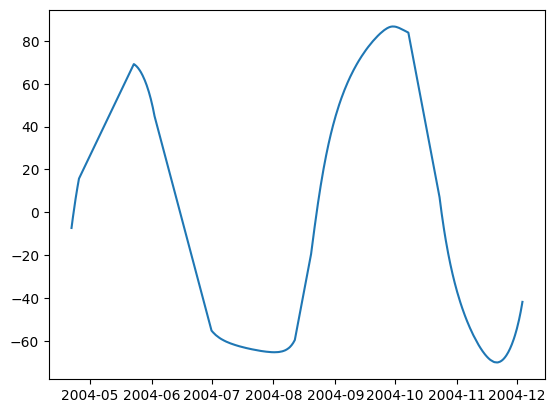

In [11]:
plt.plot(times[:1000], latitudes[:1000])

In [80]:
date_index = np.random.choice(bad_profile_indices)

<class 'numpy.int64'>
70578


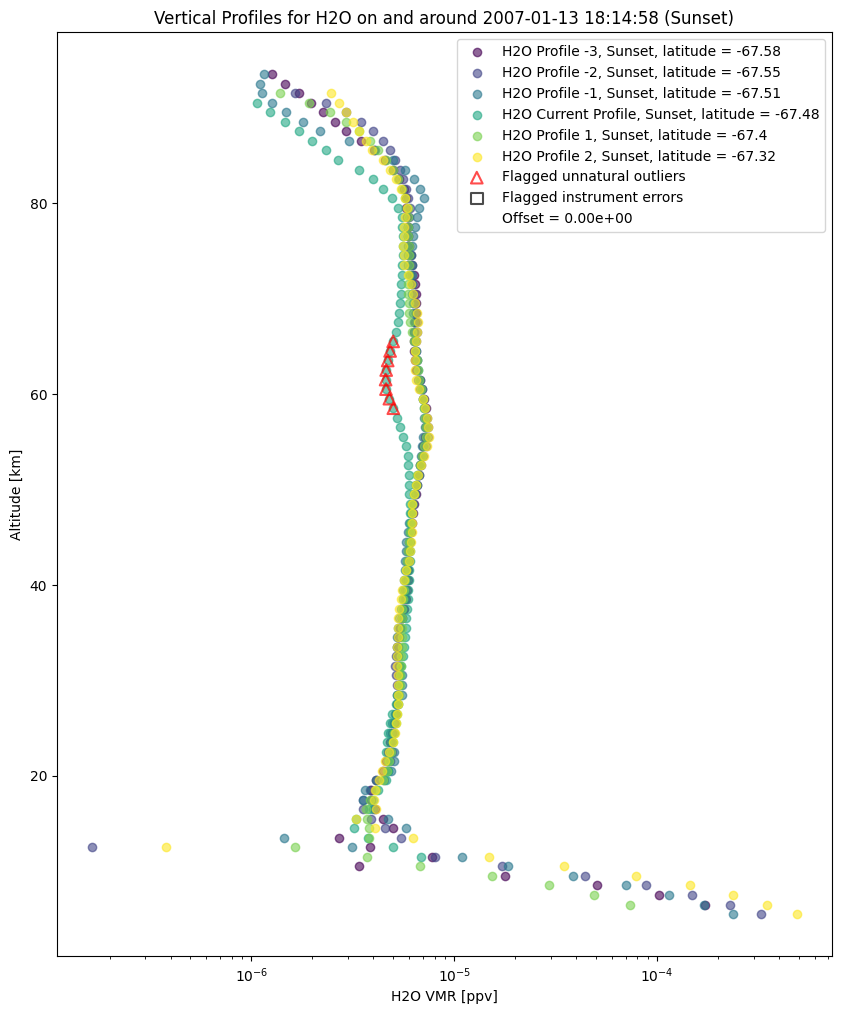

In [ ]:
reload(data_processing)
from data_processing import vertical_profile_plot as vpp
date_index = np.random.choice(bad_profile_indices)
print(date_index)
vpp('H2O', h2o_data, h2o_flags, date_index, 5)

In [ ]:
orbit = h2o_data['orbit'][date_index].values
ss = h2o_data['sunset_sunrise'][date_index].values

flag_profile = h2o_flags['quality_flag'].sel(orbit=orbit, sunset_sunrise=ss).values

In [108]:
print(times[date_index])

2023-01-14 05:10:59.009999998


In [1]:
from tabulate import tabulate

In [ ]:
years = h2o_data['year'].values

unique, counts = np.unique(years, return_counts=True)
print(tabulate(dict(zip(unique, counts)).items(), headers=["Year", "Number of samples"], tablefmt="grid"))

In [ ]:
sorted_indices = np.argsort(times.to_numpy())

sorted_years = h2o_data['year'].values[sorted_indices]

sorted_latitudes = h2o_data['latitude'].values[sorted_indices]

start_index = np.where(h2o_data['year'].values[sorted_indices] == 2017)[0][0]
end_index = np.where(h2o_data['year'].values[sorted_indices] == 2018)[0][0]

#start_index = 0
#end_index = len(sorted_latitudes)
end_index = start_index + 2760

sunset_latitudes = [sorted_latitudes[i] for i in range(start_index, end_index) if h2o_data['sunset_sunrise'].values[sorted_indices[i]] in [0, 2]]
sunrise_latitudes = [sorted_latitudes[i] for i in range(start_index, end_index) if h2o_data['sunset_sunrise'].values[sorted_indices[i]] in [1, 3]]

sunset_diff = np.abs(np.diff(sunset_latitudes))
sunrise_diff = np.abs(np.diff(sunrise_latitudes))

plt.figure(figsize=(10, 6))
#plt.plot(sunset_latitudes[1:len(sunset_latitudes)], sunset_diff, label = 'Sunset')
plt.plot(sunrise_latitudes[1:len(sunrise_latitudes)], sunrise_diff, label = 'Sunrise')
plt.xlabel('Latitude')
plt.ylabel('Latitude Difference between adjacent profiles')
plt.legend()
plt.show()




In [ ]:
sorted_times = times.to_numpy()[sorted_indices]

time_diff = sorted_times[end_index] - sorted_times[start_index]
print(sorted_times[start_index], sorted_times[end_index])
print(time_diff.astype('timedelta64[D]').item().days)

print((time_diff/2760).astype('timedelta64[m]'))

In [ ]:
sunrise_times = [sorted_times[i] for i in range(start_index, end_index) if h2o_data['sunset_sunrise'].values[sorted_indices[i]] in [1, 3]]

plt.plot(sunrise_times, sunrise_latitudes)
plt.xlabel('Time')
plt.ylabel('Latitude')

In [18]:
print(h2o_flags.coords)

Coordinates:
  * altitude        (altitude) float32 600B 0.5 1.5 2.5 ... 147.5 148.5 149.5
  * index           (index) object 1MB MultiIndex
  * orbit           (index) int32 505kB 3725 3727 3729 ... 99290 99291 99303
  * sunset_sunrise  (index) int8 126kB 1 1 1 1 1 1 1 1 1 1 ... 2 2 2 2 2 2 2 2 2


In [51]:
orbit_numbers = h2o_data['orbit'].values

sunset_mask = (h2o_data['sunset_sunrise'] == 0) | (h2o_data['sunset_sunrise'] == 2)

#sunset_orbits = np.unique(orbit_numbers[sunset_mask])
sunset_orbits = orbit_numbers

sunset_vmr = []
for i in sunset_orbits:
    sunset_vmr.append(h2o_data['H2O'].sel(orbit = i, altitude = 35.5).values)

sunset_vmr = np.concatenate(sunset_vmr)

mask = sunset_vmr >= 0
sunset_vmr = sunset_vmr[mask]

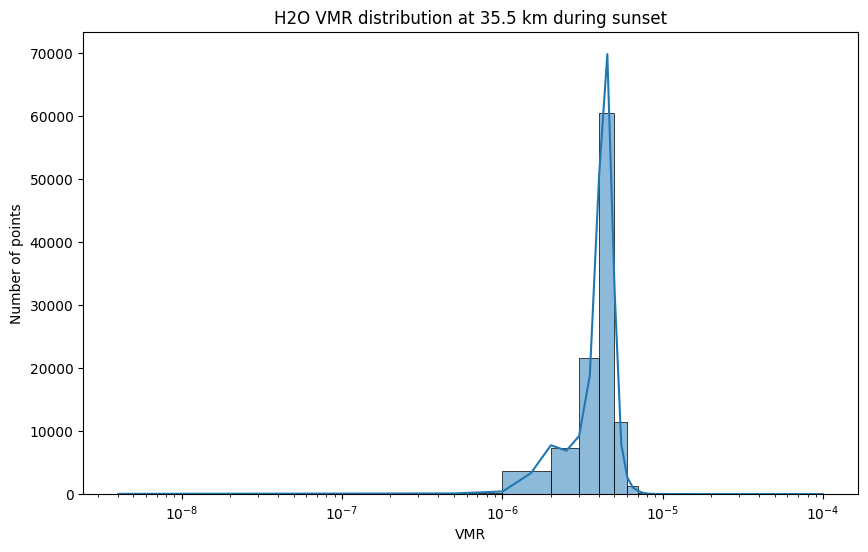

In [34]:
import seaborn as sns
plt.ion()
plt.figure(figsize=(10, 6))
sns.histplot(sunset_vmr, bins=100, kde=True)
plt.xlabel('VMR')
plt.xscale('log')
plt.ylabel('Number of points')
plt.title('H2O VMR distribution at 35.5 km during sunset')
plt.show()

In [17]:
alt = 15.5

vmr_alt = h2o_data['H2O'].sel(altitude=alt).values

sunset_mask = (h2o_data['sunset_sunrise'] == 0) | (h2o_data['sunset_sunrise'] == 2)

vmr_alt = vmr_alt[sunset_mask]

vmr_alt = vmr_alt[vmr_alt >= 0]

print(vmr_alt.shape, h2o_data['H2O'].shape)

(59963,) (127136, 150)


(63001,) (127136, 150)


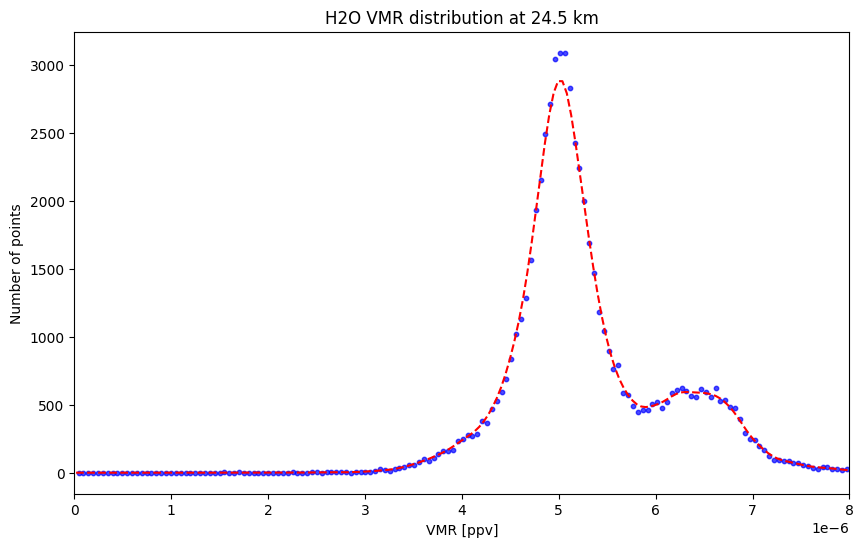

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from statsmodels.nonparametric.kde import KDEUnivariate

alt = 24.5

vmr_alt = h2o_data['H2O'].sel(altitude=alt).values

sunset_mask = (h2o_data['sunset_sunrise'] == 0) | (h2o_data['sunset_sunrise'] == 2)

vmr_alt = vmr_alt[sunset_mask]

vmr_alt = vmr_alt[vmr_alt >= 0]

print(vmr_alt.shape, h2o_data['H2O'].shape)

# Enable interactive mode
plt.ion()

# Compute histogram manually
num_bins = 900

bin_counts, bin_edges = np.histogram(vmr_alt, bins=num_bins)

# Compute bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create figure
plt.figure(figsize=(10, 6))

# Scatter plot to represent histogram as points
plt.scatter(bin_centers, bin_counts, color='blue', label='Histogram', alpha=0.7, s=10)

def adaptive_bw(x):
    return 0.3 * np.std(x) * (len(x) ** (-1/5))

# Compute KDE
kde = gaussian_kde(vmr_alt, bw_method='scott')
x_vals = np.linspace(min(vmr_alt), max(vmr_alt), 1000)
kde_vals = kde(x_vals)
# Scale KDE to match histogram
kde_scaled = kde_vals * len(vmr_alt) * (max(vmr_alt) - min(vmr_alt)) / num_bins

# Plot KDE as a dashed line
plt.plot(x_vals, kde_scaled, linestyle='dashed', color='red', label='KDE')

# Labels and title
plt.xlabel('VMR [ppv]')
plt.ylabel('Number of points')
plt.xlim(0, 8*10**-6)
plt.title(f'H2O VMR distribution at {alt} km')

# Show plot
plt.show()

In [19]:
import plotly.graph_objects as go
import numpy as np
from scipy.stats import gaussian_kde

sunset_vmr = vmr_alt

# Compute histogram manually
bin_counts, bin_edges = np.histogram(sunset_vmr, bins=1000)

# Compute bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Compute KDE
kde = gaussian_kde(sunset_vmr)
x_vals = np.linspace(min(sunset_vmr), max(sunset_vmr), 1000)
kde_vals = kde(x_vals)

# Scale KDE to match histogram
kde_scaled = kde_vals * len(sunset_vmr) * (max(sunset_vmr) - min(sunset_vmr)) / 1000

# Create Plotly figure
fig = go.Figure()

# Add histogram as scatter points
fig.add_trace(go.Scatter(
    x=bin_centers,
    y=bin_counts,
    mode='markers',
    marker=dict(color='blue', opacity=0.7),
    name='Histogram'
))

# Add KDE line
fig.add_trace(go.Scatter(
    x=x_vals,
    y=kde_scaled,
    mode='lines',
    line=dict(dash='dash', color='red'),
    name='KDE'
))

# Labels and title
fig.update_layout(
    title="H2O VMR Distribution at 35.5 km During Sunset",
    xaxis_title="VMR",
    yaxis_title="Number of Points",
    hovermode="x",
)

# Show interactive plot
fig.show()

(63001,) (127136, 150)


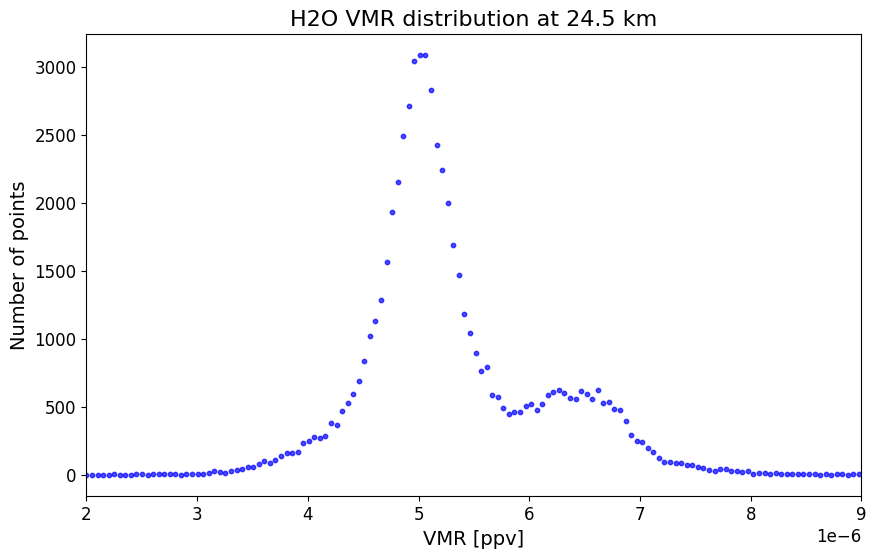

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from statsmodels.nonparametric.kde import KDEUnivariate

alt = 24.5

vmr_alt = h2o_data['H2O'].sel(altitude=alt).values

sunset_mask = (h2o_data['sunset_sunrise'] == 0) | (h2o_data['sunset_sunrise'] == 2)

vmr_alt = vmr_alt[sunset_mask]

vmr_alt = vmr_alt[vmr_alt >= 0]

print(vmr_alt.shape, h2o_data['H2O'].shape)

# Enable interactive mode
plt.ion()

# Compute histogram manually
num_bins = 900

bin_counts, bin_edges = np.histogram(vmr_alt, bins=num_bins)

# Compute bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create figure
plt.figure(figsize=(10, 6))

# Scatter plot to represent histogram as points
plt.scatter(bin_centers, bin_counts, color='blue', label='Histogram', alpha=0.7, s=10)


# Labels and title
plt.xlabel('VMR [ppv]', fontsize=14)
plt.ylabel('Number of points', fontsize=14)
plt.xlim(2*10**-6, 9*10**-6)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax = plt.gca()  # Get current axes
ax.xaxis.get_offset_text().set_fontsize(12)  # Change font size of offset notation
plt.title(f'H2O VMR distribution at {alt} km', fontsize=16)
plt.savefig('h2o_vmr_hist_24.5km.png')
# Show plot
plt.show()